# Spectral transport can split mass

Two horizontal source points are transported to two vertical target
points. Every matching has operator cost $2$; the uniform coupling
has displacement moment $I$ and operator cost $1$. This illustrates
why permutation heuristics need not solve spectral OT.

`solve_transport` solves the full convex coupling problem for
$p\in\{1,2,\infty\}$. Its cost is the **squared** distance. Conic
results are numerical optima, not exact primal-dual certificates.

Run from an environment with `pip install -e '.[notebooks,transport]'` from
the repository root. In Colab, first run
`%pip install 'muon-dynamics[notebooks,transport] @ git+https://github.com/gpeyre/muon-dynamics.git'`.
All particle arrays have particles in rows. No training data are downloaded.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import muon_dynamics as md

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})


Matplotlib is building the font cache; this may take a moment.


In [2]:
x = np.array([[-1., 0.], [1., 0.]])
y = np.array([[0., -1.], [0., 1.]])
results = [md.solve_transport(x, y, p) for p in [1, 2, np.inf]]
np.testing.assert_allclose([r.squared_cost for r in results], [2, np.sqrt(2), 1], atol=1e-5)
for p, result in zip([1, 2, np.inf], results):
    print(f"p={p:g}: cost={result.squared_cost:.6f}, "
          f"marginal error={result.marginal_error:.2e}, solver={result.solver}")


p=1: cost=2.000000, marginal error=0.00e+00, solver=scipy.linear_sum_assignment
p=2: cost=1.414214, marginal error=0.00e+00, solver=CLARABEL
p=inf: cost=1.000000, marginal error=4.07e-09, solver=SCS


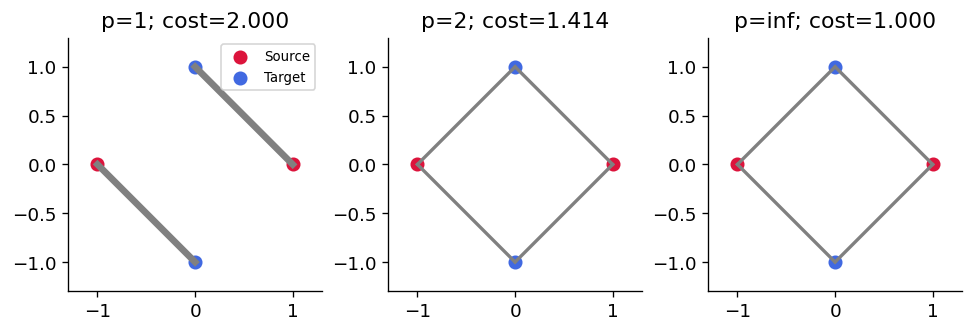

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(8, 3), constrained_layout=True)
for ax, p, result in zip(axes, [1, 2, np.inf], results):
    for i in range(2):
        for j in range(2):
            ax.plot([x[i, 0], y[j, 0]], [x[i, 1], y[j, 1]],
                    color="gray", lw=8*max(result.plan[i, j], 0))
    ax.scatter(*x.T, s=55, color="crimson", label="Source")
    ax.scatter(*y.T, s=55, color="royalblue", label="Target")
    ax.set(title=f"p={p:g}; cost={result.squared_cost:.3f}", aspect="equal",
           xlim=(-1.3, 1.3), ylim=(-1.3, 1.3))
axes[0].legend(fontsize=8)
fig.savefig("03_static_transport.png", dpi=130)
plt.show()
